Image count effect (within point-year): 0.0240 ± 0.0018 NDVI per ln(images)
Image count effect (naive, confounded with trend): 0.1503
Mean images/month before 2013: 4.7, from 2013: 10.5 -> implied bias +0.019 NDVI


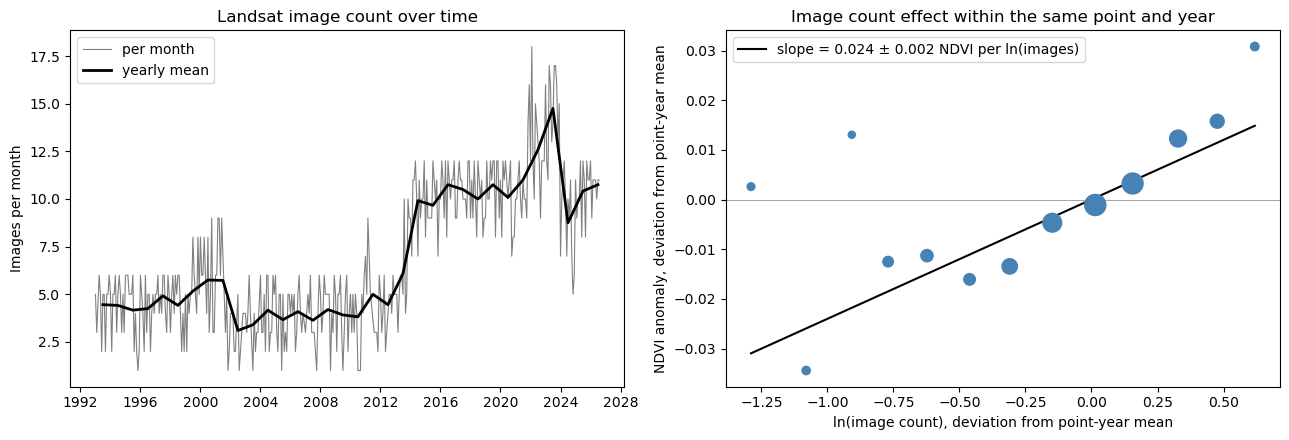


Tipping points with and without image count correction:
          uncorrected  corrected
type                            
increase          138        133
decline            64         67

Tipping points used for plots (corrected):
type   decline  increase  points_with_any  points_in_class
class                                                     
1            1         0                1               30
3           33        55               26               30
4           14        31               21               30
5           19        47               19               30


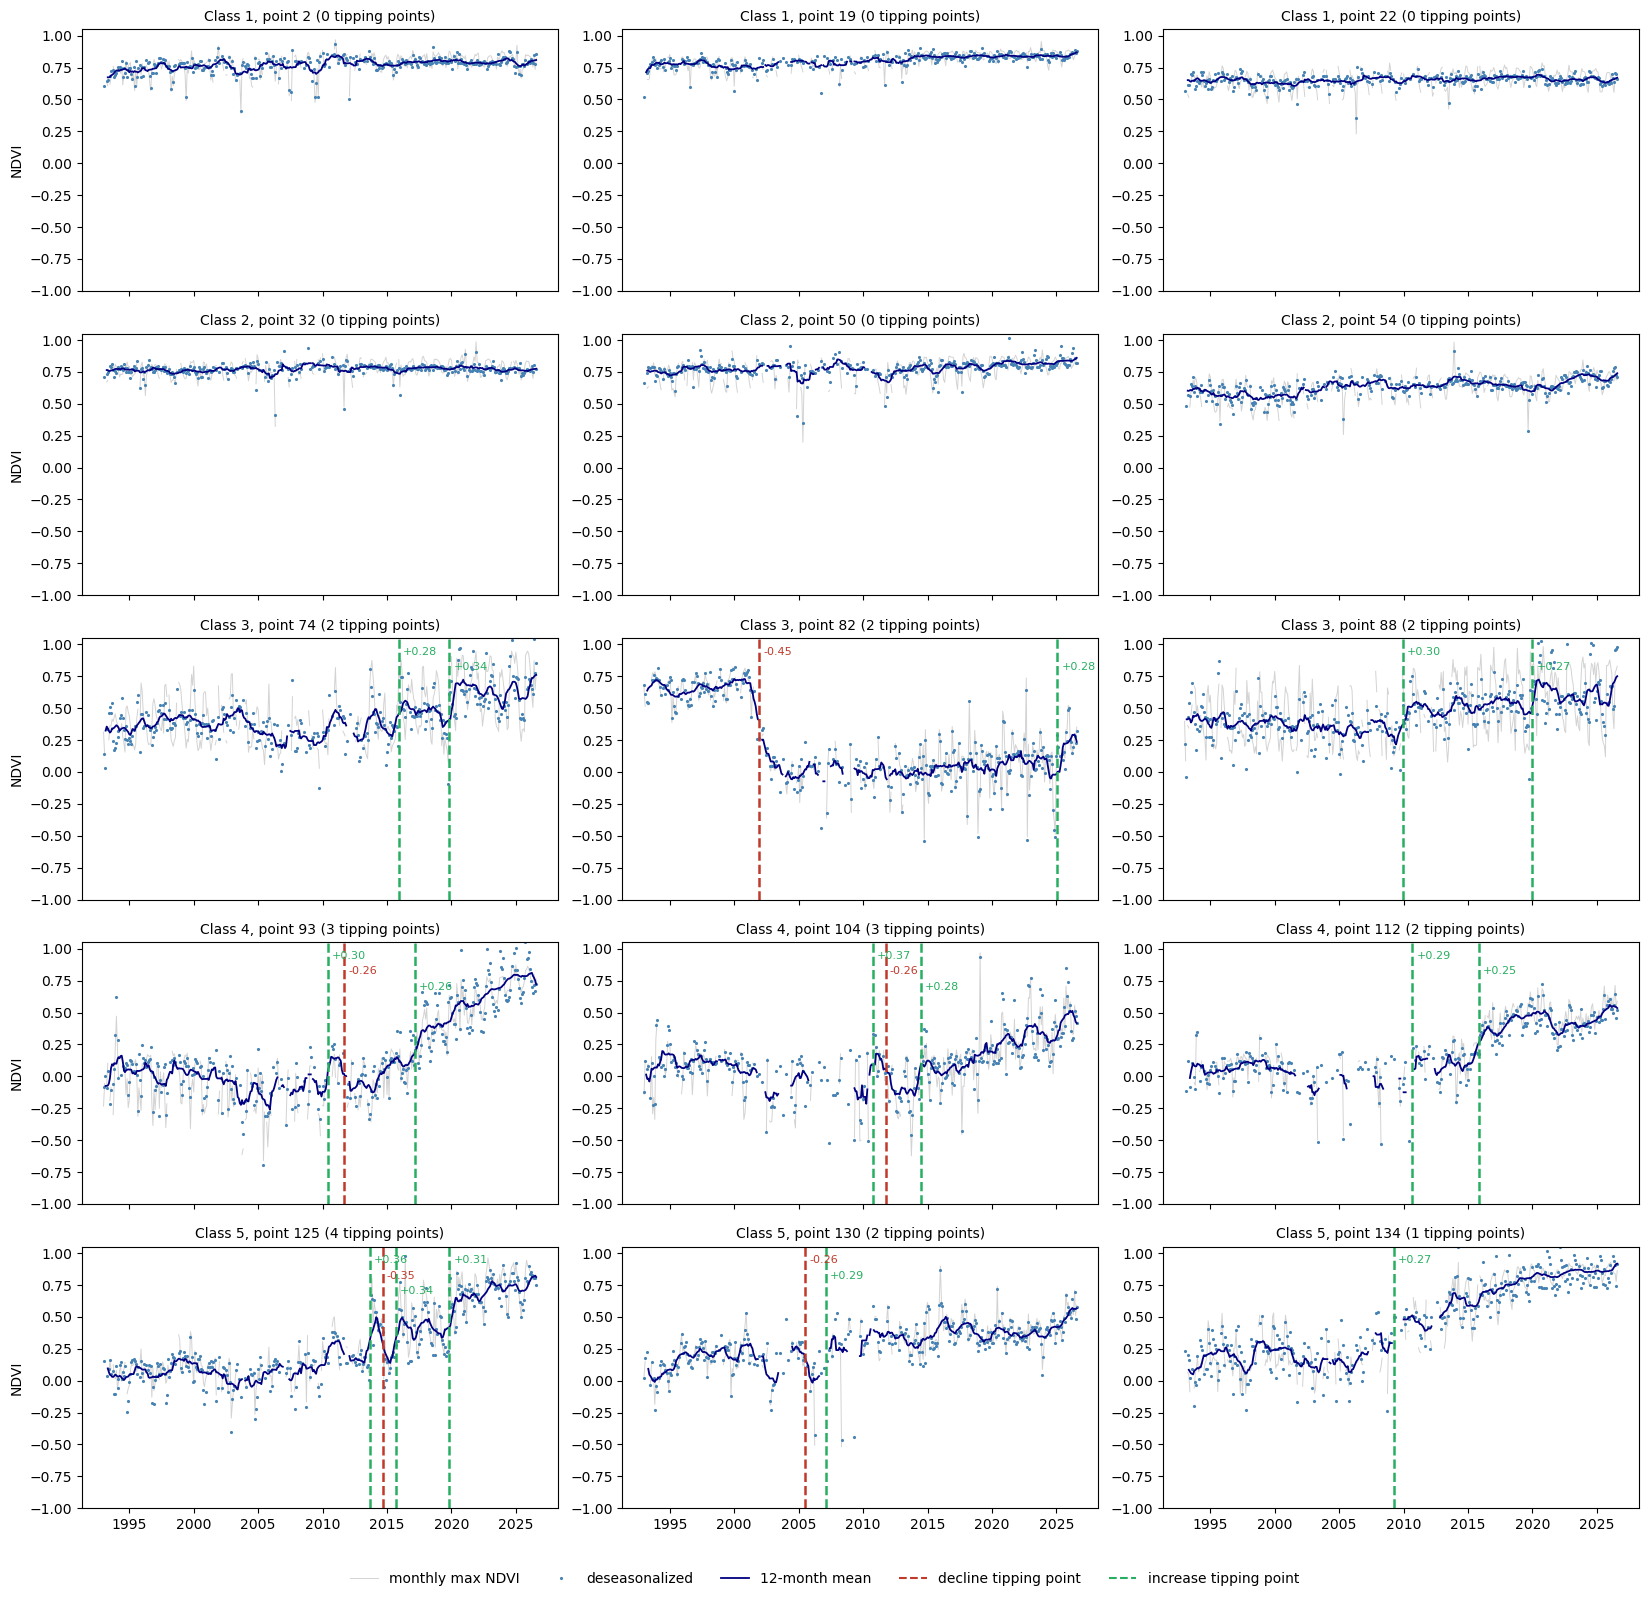

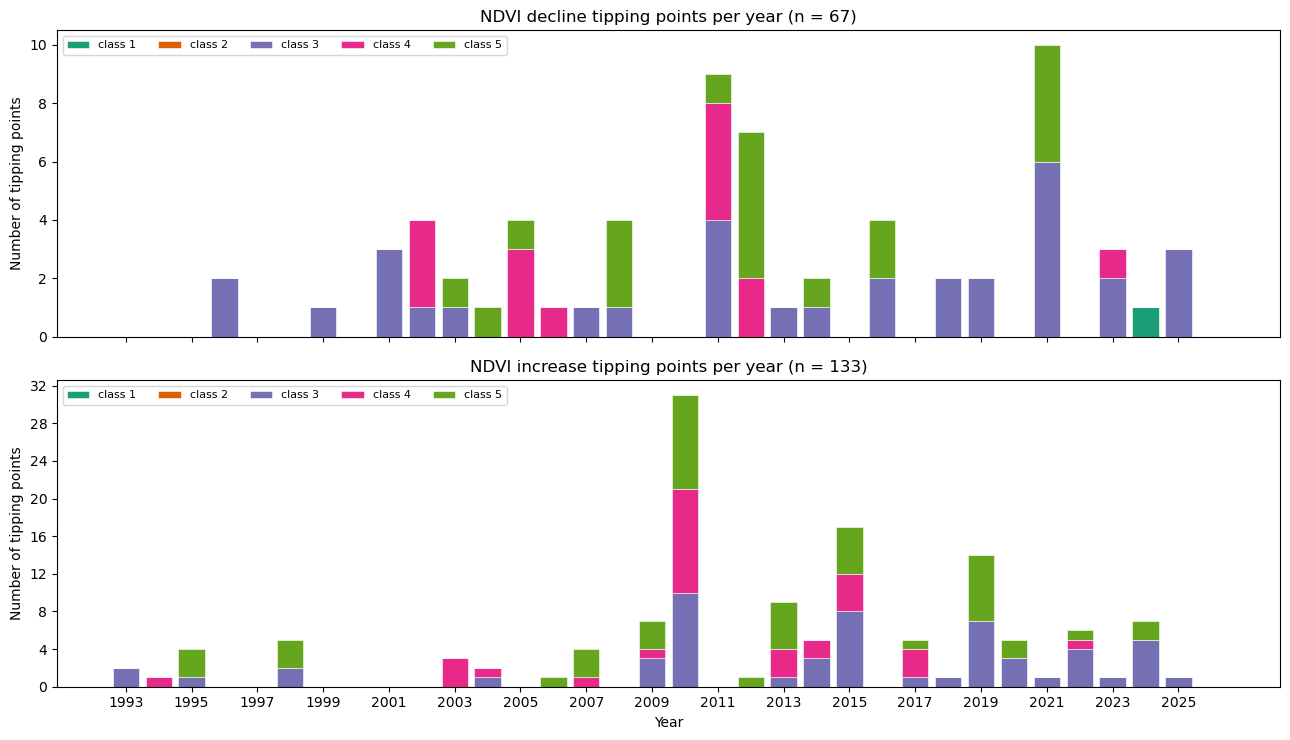


Outputs written to /Users/karlijnvanderhulst/Documents/AAAstudie/MDP/tipping_point_output


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from pathlib import Path

CSV_PATH = "Sisal_Landsat_monthly_max_NDVI_per_point.csv"
OUT_DIR = Path("tipping_point_output")
THRESHOLD = 0.25
WINDOW = 12
MIN_VALID = 6
MIN_SEPARATION = 12
CORRECT_IMAGE_COUNT = True
N_EXAMPLES_PER_CLASS = 3
SEED = 42

DECLINE_COLOR = "#c0392b"
INCREASE_COLOR = "#27ae60"
CLASS_COLORS = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]


def load_data(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
    df["ln_n"] = np.log(df["n_images_that_month"])
    return df.sort_values(["point_id", "date"]).reset_index(drop=True)


def estimate_image_count_effect(df):
    clim = df.groupby(["point_id", "month"])["ndvi_max"].transform("median")
    anom = df["ndvi_max"] - clim
    groups = [df["point_id"], df["year"]]
    y = anom - anom.groupby(groups).transform("mean")
    x = df["ln_n"] - df["ln_n"].groupby(groups).transform("mean")
    beta = (x * y).sum() / (x * x).sum()
    resid = y - beta * x
    n_groups = df.groupby(["point_id", "year"]).ngroups
    dof = len(df) - n_groups - 1
    se = np.sqrt((resid ** 2).sum() / dof / (x * x).sum())

    x_naive = df["ln_n"] - df.groupby("point_id")["ln_n"].transform("mean")
    y_naive = anom - anom.groupby(df["point_id"]).transform("mean")
    beta_naive = (x_naive * y_naive).sum() / (x_naive * x_naive).sum()
    return beta, se, beta_naive, x, y


def apply_image_count_correction(df, beta):
    ln_ref = np.log(df["n_images_that_month"].median())
    df["ndvi_corr"] = df["ndvi_max"] - beta * (df["ln_n"] - ln_ref)
    return df


def deseasonalize(df, value_col):
    clim = df.groupby(["point_id", "month"])[value_col].transform("median")
    level = df.groupby("point_id")[value_col].transform("median")
    df["ndvi_deseason"] = df[value_col] - clim + level
    return df


def to_regular_series(df, col):
    full_index = pd.date_range(df["date"].min(), df["date"].max(), freq="MS")
    wide = df.pivot(index="date", columns="point_id", values=col)
    return wide.reindex(full_index)


def window_difference(series):
    before = series.shift(1).rolling(WINDOW, min_periods=MIN_VALID).mean()
    after = series.rolling(WINDOW, min_periods=MIN_VALID).mean().shift(-(WINDOW - 1))
    return after - before, before, after


def find_events(diff, sign):
    exceed = (sign * diff) > THRESHOLD
    run_id = (exceed != exceed.shift()).cumsum()
    candidates = []
    for _, run in diff[exceed].groupby(run_id[exceed]):
        idx = (sign * run).idxmax()
        candidates.append((idx, run[idx]))

    kept = []
    for date, mag in sorted(candidates, key=lambda c: -abs(c[1])):
        too_close = any(abs((date.year - d.year) * 12 + date.month - d.month) < MIN_SEPARATION for d, _ in kept)
        if not too_close:
            kept.append((date, mag))
    return sorted(kept)


def detect_tipping_points(wide, classes):
    records = []
    diffs = {}
    for pid in wide.columns:
        diff, before, after = window_difference(wide[pid])
        diffs[pid] = diff
        for sign, label in [(-1, "decline"), (1, "increase")]:
            for date, mag in find_events(diff, sign):
                records.append({
                    "point_id": pid,
                    "class": classes[pid],
                    "date": date,
                    "year": date.year,
                    "type": label,
                    "delta_ndvi": mag,
                    "mean_before": before[date],
                    "mean_after": after[date],
                })
    events = pd.DataFrame(records, columns=["point_id", "class", "date", "year", "type",
                                            "delta_ndvi", "mean_before", "mean_after"])
    return events, pd.DataFrame(diffs)


def plot_image_count_diagnostic(df, x, y, beta, se, path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    per_month = df.groupby("date")["n_images_that_month"].first()
    axes[0].plot(per_month.index, per_month.values, color="grey", lw=0.8, label="per month")
    yearly = per_month.groupby(per_month.index.year).mean()
    axes[0].plot(pd.to_datetime(yearly.index.astype(str)) + pd.DateOffset(months=6), yearly.values,
                 color="black", lw=2, label="yearly mean")
    axes[0].set_ylabel("Images per month")
    axes[0].set_title("Landsat image count over time")
    axes[0].legend()

    bins = pd.cut(x, 15)
    binned = pd.DataFrame({"x": x, "y": y}).groupby(bins, observed=True).agg(
        x=("x", "mean"), y=("y", "mean"), n=("y", "size"))
    binned = binned[binned["n"] > 100]
    axes[1].scatter(binned["x"], binned["y"], s=np.sqrt(binned["n"]) * 2, color="steelblue", zorder=3)
    xs = np.linspace(binned["x"].min(), binned["x"].max(), 50)
    axes[1].plot(xs, beta * xs, color="black", lw=1.5,
                 label=f"slope = {beta:.3f} ± {se:.3f} NDVI per ln(images)")
    axes[1].axhline(0, color="grey", lw=0.5)
    axes[1].set_xlabel("ln(image count), deviation from point-year mean")
    axes[1].set_ylabel("NDVI anomaly, deviation from point-year mean")
    axes[1].set_title("Image count effect within the same point and year")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def plot_example_points(raw_wide, deseason_wide, diffs, events, classes, path):
    rng = np.random.default_rng(SEED)
    class_list = sorted(set(classes.values()))
    fig, axes = plt.subplots(len(class_list), N_EXAMPLES_PER_CLASS,
                             figsize=(5.5 * N_EXAMPLES_PER_CLASS, 3.2 * len(class_list)),
                             sharex=True, squeeze=False)

    for row, cls in enumerate(class_list):
        pids = [p for p, c in classes.items() if c == cls]
        chosen = rng.choice(pids, size=min(N_EXAMPLES_PER_CLASS, len(pids)), replace=False)
        for col, pid in enumerate(sorted(chosen)):
            ax = axes[row, col]
            ax.plot(raw_wide.index, raw_wide[pid], color="lightgrey", lw=0.7, label="monthly max NDVI")
            ax.plot(deseason_wide.index, deseason_wide[pid], ".", color="steelblue", ms=2.5,
                    label="deseasonalized")
            smooth = deseason_wide[pid].rolling(WINDOW, center=True, min_periods=MIN_VALID).mean()
            ax.plot(smooth.index, smooth, color="navy", lw=1.3, label="12-month mean")

            pe = events[events["point_id"] == pid]
            for i, (_, ev) in enumerate(pe.sort_values("date").iterrows()):
                color = DECLINE_COLOR if ev["type"] == "decline" else INCREASE_COLOR
                ax.axvline(ev["date"], color=color, lw=1.8, ls="--")
                ax.annotate(f"{ev['delta_ndvi']:+.2f}", (ev["date"], 1.0), xycoords=("data", "axes fraction"),
                            xytext=(3, -12 - 11 * (i % 3)), textcoords="offset points", color=color, fontsize=8)

            ax.set_title(f"Class {cls}, point {pid} ({len(pe)} tipping points)", fontsize=10)
            ax.set_ylim(-1, 1.05)
            if col == 0:
                ax.set_ylabel("NDVI")
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        for col in range(len(chosen), N_EXAMPLES_PER_CLASS):
            axes[row, col].axis("off")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    handles += [plt.Line2D([], [], color=DECLINE_COLOR, ls="--"), plt.Line2D([], [], color=INCREASE_COLOR, ls="--")]
    labels += ["decline tipping point", "increase tipping point"]
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(path, dpi=150)
    plt.show()


def plot_stacked_per_year(events, years, classes, path):
    class_list = sorted(set(classes.values()))
    fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

    for ax, kind in zip(axes, ["decline", "increase"]):
        sub = events[events["type"] == kind]
        counts = (sub.groupby(["year", "class"]).size().unstack(fill_value=0)
                  .reindex(index=years, columns=class_list, fill_value=0))
        bottom = np.zeros(len(years))
        for i, cls in enumerate(class_list):
            ax.bar(years, counts[cls].values, bottom=bottom, color=CLASS_COLORS[i % len(CLASS_COLORS)],
                   label=f"class {cls}", edgecolor="white", lw=0.4)
            bottom += counts[cls].values
        ax.set_ylabel("Number of tipping points")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_title(f"NDVI {kind} tipping points per year (n = {len(sub)})")
        ax.legend(ncol=len(class_list), fontsize=8, loc="upper left")

    axes[1].set_xlabel("Year")
    axes[1].set_xticks(years[::2])
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def run_detection(df, value_col, classes):
    df = deseasonalize(df.copy(), value_col)
    wide = to_regular_series(df, "ndvi_deseason")
    events, diffs = detect_tipping_points(wide, classes)
    return df, wide, events, diffs


def main():
    OUT_DIR.mkdir(exist_ok=True)
    df = load_data(CSV_PATH)
    classes = df.groupby("point_id")["traj"].first().to_dict()

    beta, se, beta_naive, x, y = estimate_image_count_effect(df)
    print(f"Image count effect (within point-year): {beta:.4f} ± {se:.4f} NDVI per ln(images)")
    print(f"Image count effect (naive, confounded with trend): {beta_naive:.4f}")
    n_early = df.loc[df["year"] < 2013, "n_images_that_month"].mean()
    n_late = df.loc[df["year"] >= 2013, "n_images_that_month"].mean()
    print(f"Mean images/month before 2013: {n_early:.1f}, from 2013: {n_late:.1f} "
          f"-> implied bias {beta * np.log(n_late / n_early):+.3f} NDVI")
    plot_image_count_diagnostic(df, x, y, beta, se, OUT_DIR / "image_count_effect.png")

    df = apply_image_count_correction(df, beta)
    _, _, events_raw, _ = run_detection(df, "ndvi_max", classes)
    value_col = "ndvi_corr" if CORRECT_IMAGE_COUNT else "ndvi_max"
    df, wide, events, diffs = run_detection(df, value_col, classes)

    comparison = pd.DataFrame({
        "uncorrected": events_raw["type"].value_counts(),
        "corrected": events["type"].value_counts(),
    }).fillna(0).astype(int)
    print("\nTipping points with and without image count correction:")
    print(comparison)

    print(f"\nTipping points used for plots ({'corrected' if CORRECT_IMAGE_COUNT else 'uncorrected'}):")
    summary = events.groupby(["class", "type"]).size().unstack(fill_value=0)
    summary["points_with_any"] = events.groupby("class")["point_id"].nunique()
    summary["points_in_class"] = pd.Series(classes).value_counts().sort_index()
    print(summary.fillna(0).astype(int))

    events.to_csv(OUT_DIR / "tipping_points.csv", index=False)
    raw_wide = to_regular_series(df, "ndvi_max")
    plot_example_points(raw_wide, wide, diffs, events, classes, OUT_DIR / "example_points_per_class.png")
    years = np.arange(df["year"].min(), df["year"].max() + 1)
    plot_stacked_per_year(events, years, classes, OUT_DIR / "tipping_points_per_year.png")
    print(f"\nOutputs written to {OUT_DIR.resolve()}")


if __name__ == "__main__":
    main()